In [1]:
#Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#Step 2: Extract Dataset
import zipfile
import os

zip_path = '/content/drive/MyDrive/archive (8).zip'
extract_path = '/content/drive/MyDrive/adult_dataset'

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir(extract_path))

['adult.csv']


In [3]:
#Step 3: Load Dataset
import pandas as pd

data_path = '/content/drive/MyDrive/adult_dataset/adult.csv'
df = pd.read_csv(data_path)

df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [4]:
#Step 4: Basic Data Inspection
print(df.shape)

(32561, 15)


In [5]:
#Step 4: Basic Data Inspection
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB
None


In [6]:
#Step 4: Basic Data Inspection
print(df.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64


In [7]:
#Step 5: Data Preprocessing
df.drop(['education.num','capital.gain','capital.loss'], axis=1, inplace=True)

In [8]:
#Step 6: Convert Categorical Data to Numerical
df = pd.get_dummies(df)
df.head()

,age,fnlwgt,hours.per.week,workclass_?,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia,income_<=50K,income_>50K
0,90,77053,40,True,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
1,82,132870,18,False,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,False
2,66,186061,40,True,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
3,54,140359,40,False,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,False
4,41,264663,40,False,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,False


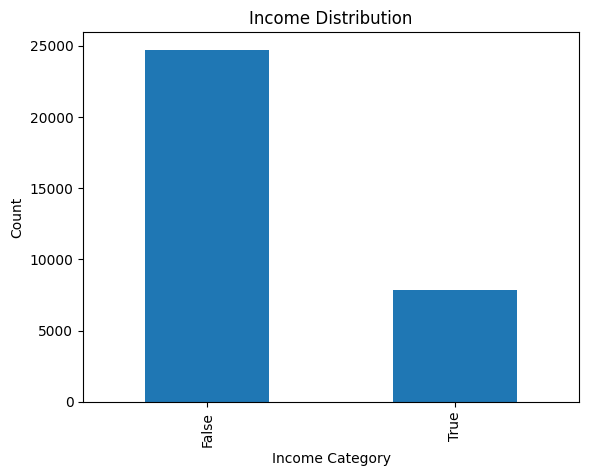

In [9]:
#Step 7: Exploratory Data Analysis (EDA)

#1. Income Distribution
import matplotlib.pyplot as plt

df['income_>50K'].value_counts().plot(kind='bar')
plt.title("Income Distribution")
plt.xlabel("Income Category")
plt.ylabel("Count")
plt.show()

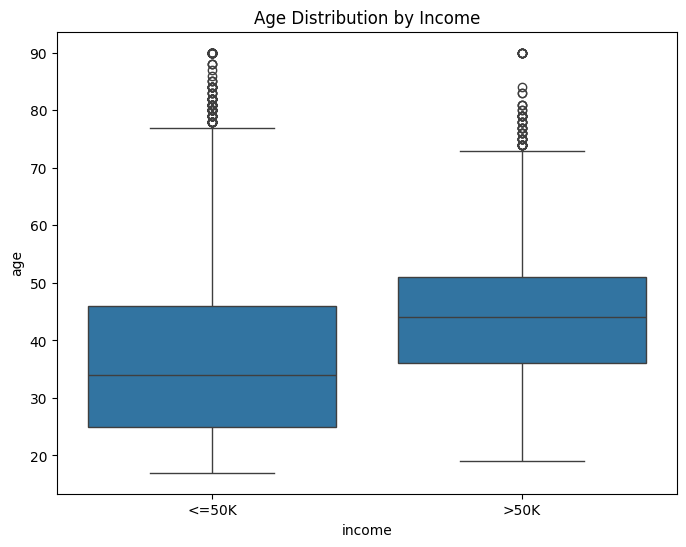

In [10]:
#Step 7: Exploratory Data Analysis (EDA)

#2. Age vs Income Boxplot
import seaborn as sns

df['income'] = df['income_>50K'].apply(lambda x: '>50K' if x==1 else '<=50K')

plt.figure(figsize=(8,6))
sns.boxplot(x='income', y='age', data=df)
plt.title("Age Distribution by Income")
plt.show()

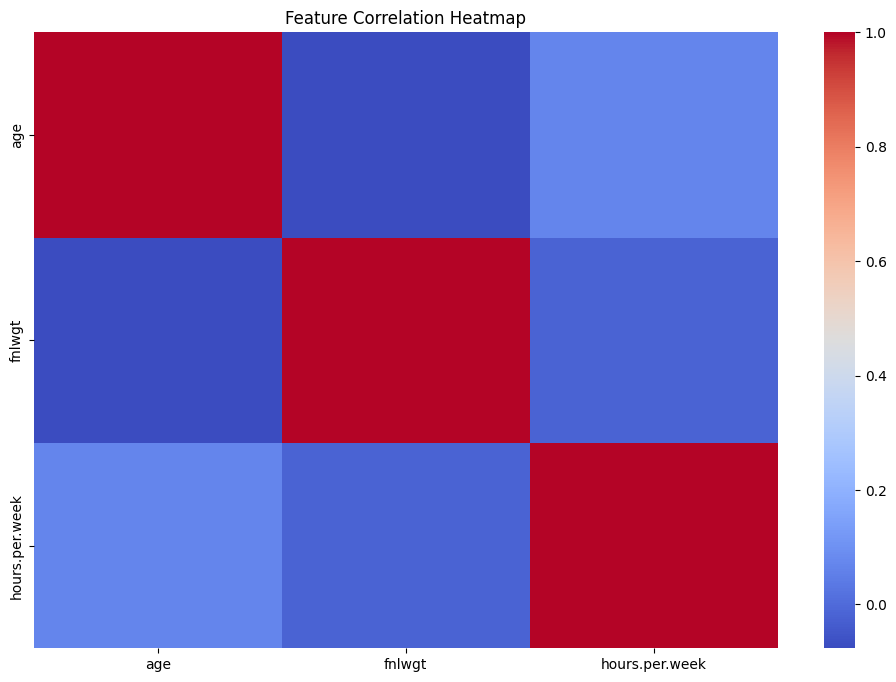

In [12]:
#Step 7: Exploratory Data Analysis (EDA)

#3. Correlation Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64','float64','uint8'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')

plt.title("Feature Correlation Heatmap")
plt.show()

In [13]:
#Step 8: Define Features and Target
X = df.drop(['income_<=50K','income_>50K','income'], axis=1)
y = df['income_>50K']

In [14]:
#Step 9: Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [15]:
#Step 10: Train Random Forest Model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, n_estimators=200, random_state=42)

In [16]:
#Step 11: Model Prediction
y_pred = model.predict(X_test)

In [17]:
#Step 12: Model Evaluation

#1. Accuracy & Classification Report
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8366344234607708
              precision    recall  f1-score   support

       False       0.86      0.93      0.90      4976
        True       0.71      0.53      0.60      1537

    accuracy                           0.84      6513
   macro avg       0.79      0.73      0.75      6513
weighted avg       0.83      0.84      0.83      6513



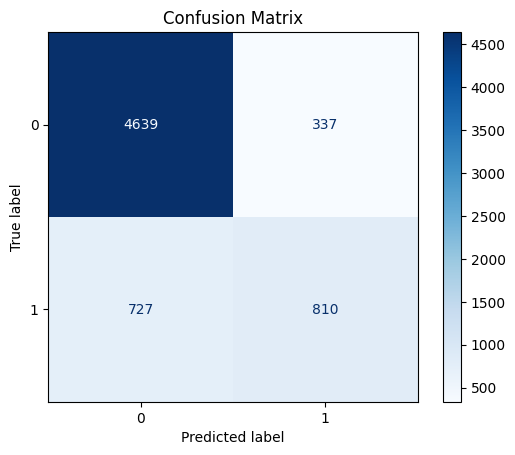

In [18]:
#Step 13: Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

In [19]:
#Step 14: Calculate Performance Metrics
TN, FP, FN, TP = cm.ravel()

accuracy = (TP+TN)/(TP+TN+FP+FN)
precision = TP/(TP+FP)
recall = TP/(TP+FN)
f1 = 2*(precision*recall)/(precision+recall)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.8366344234607708
Precision: 0.7061900610287707
Recall   : 0.5270006506180872
F1 Score : 0.6035767511177348


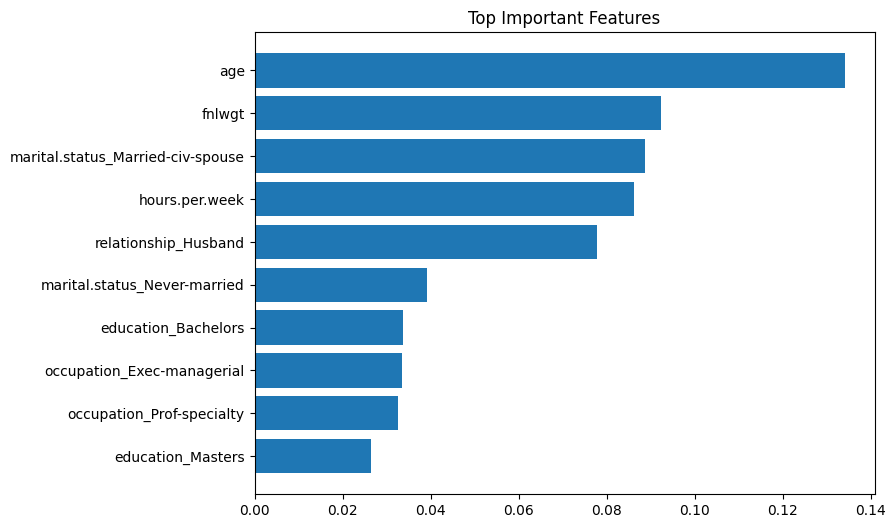

In [20]:
#Step 15: Feature Importance Plot
import numpy as np

importances = model.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(8,6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X.columns[indices])
plt.title("Top Important Features")
plt.show()